In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from dataset import categorical_attributes

In [6]:
def frequency_categorical_attribute(df, categorical_attribute):
    """
    Muestra la frecuencia con la que aparece una categoria de un atributo categorico
    Muestra un grafico de barras mostrando cada categoria y la frecuencia con la que aparece
    """
    plt.figure(figsize=(10, 6))
    
    # Contamos la frecuencia de cada valor en la columna categórica
    conteo = df[categorical_attribute].value_counts()
    
    # Creamos el gráfico de barras
    sns.barplot(x=conteo.index, y=conteo.values, palette='viridis')
    plt.title(f'Frecuencia de instancias en: {categorical_attribute}')
    plt.xlabel(categorical_attribute)
    plt.ylabel('Frecuencia (Conteo)')
    plt.xticks(rotation=45, ha='right') # Rotamos etiquetas para mejor lectura
    plt.tight_layout()
    plt.show()

def frequency_categorical_attributes(df, categorical_attributes):
    """
    Muestra la frecuencia con la que aparece una categoria de todos los atributos categoricos
    Muestra un grafico de barras por cada atributo categorico, mostrando cada categoria y la frecuencia con la que aparece
    """
    for attrib in categorical_attributes:
        frequency_categorical_attribute(df, categorical_atribute=attrib)


def umap_categorical_attribute(df, categorical_attribute, metric='euclidean'):

    """
    1. Prepara los datos seleccionando solo columnas numéricas y rellenando valores nulos con 0.
    2. Aplica reducción de dimensionalidad UMAP para proyectar los datos en 2D, utilizando la métrica de distancia especificada (por defecto 'euclidean').
    3. Selecciona automáticamente una paleta de colores optimizada ('tab10' para pocas clases, 'husl' para muchas) para maximizar la distinción visual.
    4. Genera un gráfico de dispersión (Scatter Plot) donde cada punto se colorea según el atributo categórico elegido.
    """
    
    # Seleccionamos y rellenamos datos numéricos
    df_numeric = df.select_dtypes(include=['float64', 'int64']).fillna(0)
    
    # Configuramos UMAP
    reducer = umap.UMAP(
        n_neighbors=15, 
        min_dist=0.1, 
        metric=metric,
        random_state=42
    )
    embedding = reducer.fit_transform(df_numeric)
    
    # Determinamos el número de categorías para elegir la mejor paleta
    n_categorias = df[categorical_attribute].nunique()
    # Si hay 10 o menos categorías, 'tab10' es excelente. 
    # Si hay más, 'husl' o 'Set2' funcionan bien para muchas clases.
    paleta_distinguible = "tab10" if n_categorias <= 10 else "husl"

    # Creamos el gráfico de dispersión (Scatter Plot)
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=embedding[:, 0], 
        y=embedding[:, 1], 
        hue=df[categorical_attribute], 
        palette=paleta_distinguible, # Usamos la nueva paleta
        s=60, # Puntos un poco más grandes para ver mejor el color
        alpha=0.8, # Un poco menos de transparencia
        edgecolor='w', # Borde blanco fino para separar puntos solapados
        linewidth=0.5
    )
    plt.title(f'Proyección UMAP coloreada por: {categorical_attribute}')
    # Leyenda fuera del gráfico para no tapar datos
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

def umap_categorical_attributes(df, categorical_attributes, metric='euclidean'):
    """
    Aplica reducción de dimensionalidad UMAP para proyectar los datos en 2D
    Esto lo hace para cada atributo categórico.
    Es decir que muestra una proyección de los datos en 2D por cada atributo categórico.
    """
    for attrib in categorical_attributes:
        umap_categorical_attribute(df, attrib, metric)

def freq_umap_categorical_attribute(df, categorical_attribute, metric='euclidean'):
    """
    1. Muestra un gráfico de barras con la frecuencia del atributo categórico.
    2. Realiza una proyección UMAP de las variables numéricas y colorea por dicho atributo.
    """
    # --- PARTE 1: Gráfico de Barras (Frecuencia) ---
    frequency_categorical_attribute(df, categorical_attribute)
    # --- PARTE 2: Proyección con librería UMAP ---
    umap_categorical_attribute(df, categorical_attribute, metric)

def freq_umap_categorical_attribute(df, categorical_attributes=[], metric='euclidean'):
    """
    Muestra la frecuencia como tambien la proyección de todos los atributos categoricos
    Es decir que nos va a mostrar un grafico de barras y un grafico de dispersión por cada atributo categorico.
    """
    for attrib in categorical_attributes:
        freq_umap_categorical_attribute(df, attrib, metric)


In [7]:
def filter_frequent_category(df, columna, min_freq=25):
    """
    Filtra el DataFrame conservando solo las filas donde el valor de la columna
    especificada aparece al menos 'min_freq' veces.
    """
    # 1. Contamos la frecuencia de cada categoría en esa columna
    conteo = df[columna].value_counts()
    
    # 2. Identificamos qué categorías cumplen con el mínimo (>= 25)
    categorias_validas = conteo[conteo >= min_frecuencia].index.tolist()
    
    print(f"Categorías seleccionadas en '{columna}': {categorias_validas}")
    
    # 3. Filtramos el dataset original
    # (Mantenemos solo las filas cuyo valor en 'columna' está en la lista de válidas)
    df_filtrado = df[df[columna].isin(categorias_validas)].copy()
    
    return df_filtrado

def filter_frequent_categories(df, categorical_attributes=[], min_freq=25):
    """
    Filtra el DataFrame conservando solo las filas donde el valor de la columna
    especificada aparece al menos 'min_freq' veces de todas los atributos categoricos.
    """
    df_filtrado = df
    for attrib in categorical_attributes:
    # Aplicar el filtro sobre la columna 'surface_modification'
    # (Esto eliminará categorías raras que aparecen menos de 25 veces)
        df_filtrado = filtrar_categorias_frecuentes(df_filtrado, attrib, 25)

Proyección UMAP sin la Metrica Jaccard


C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


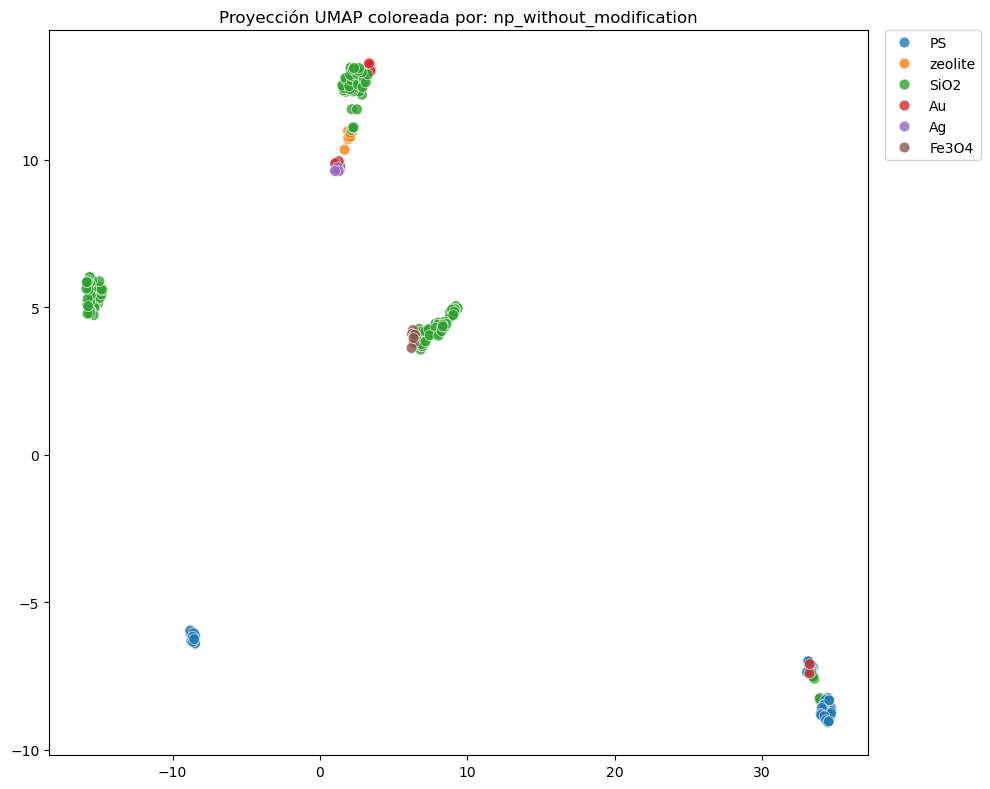

C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


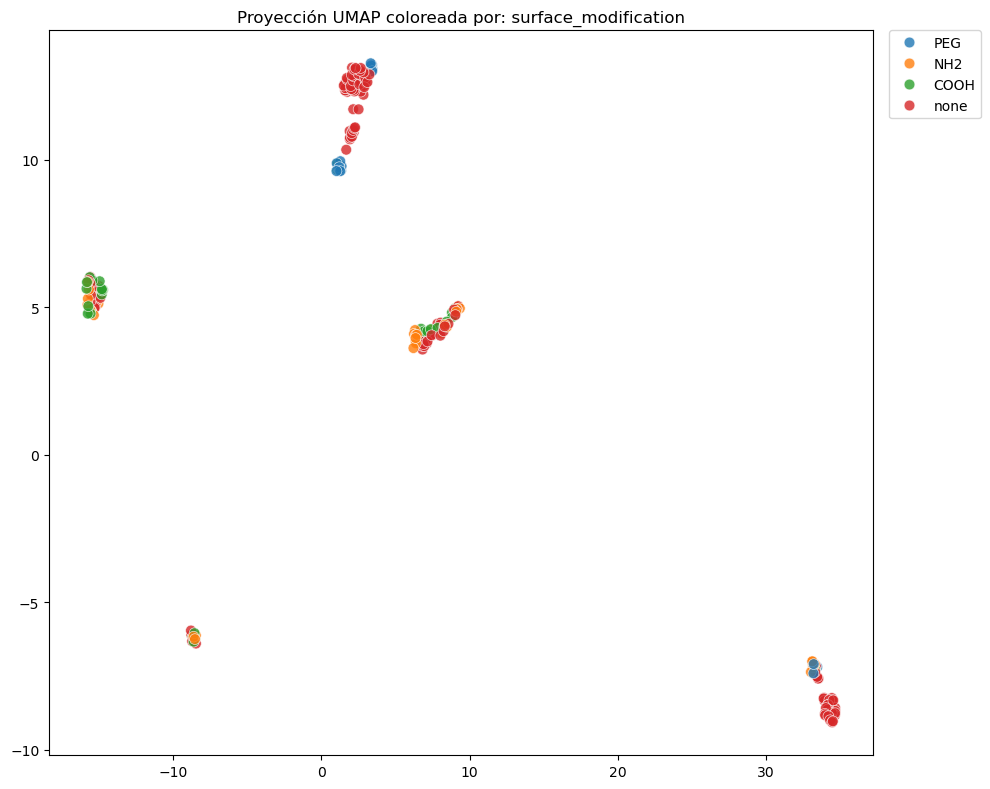

C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


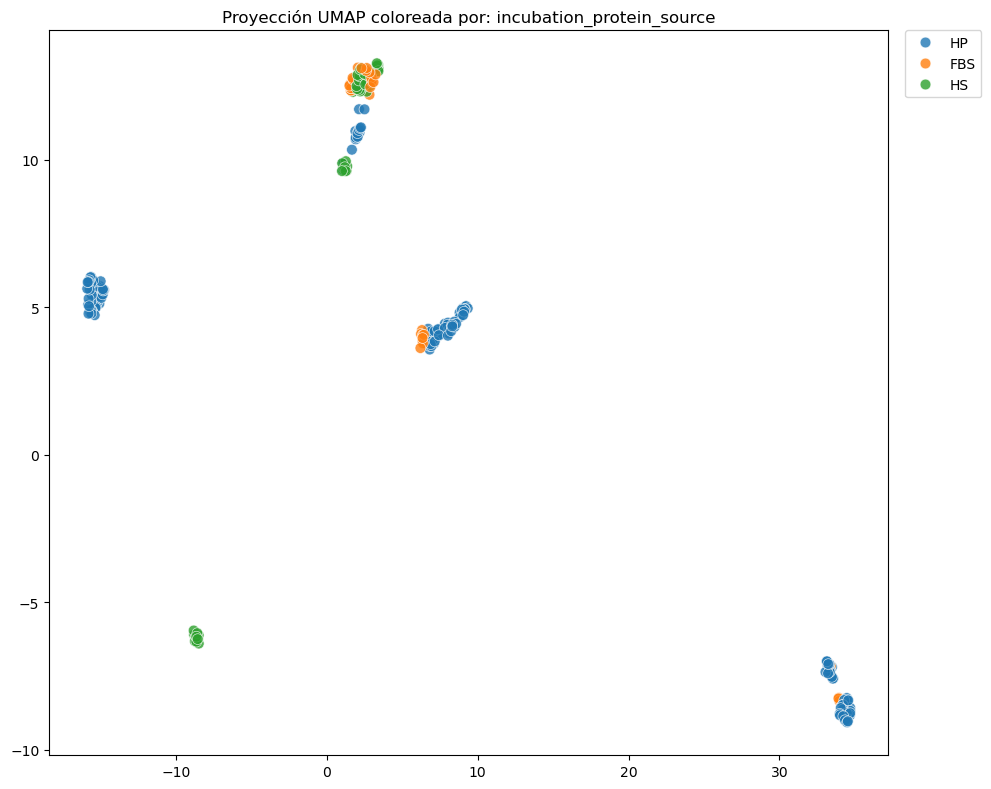

C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


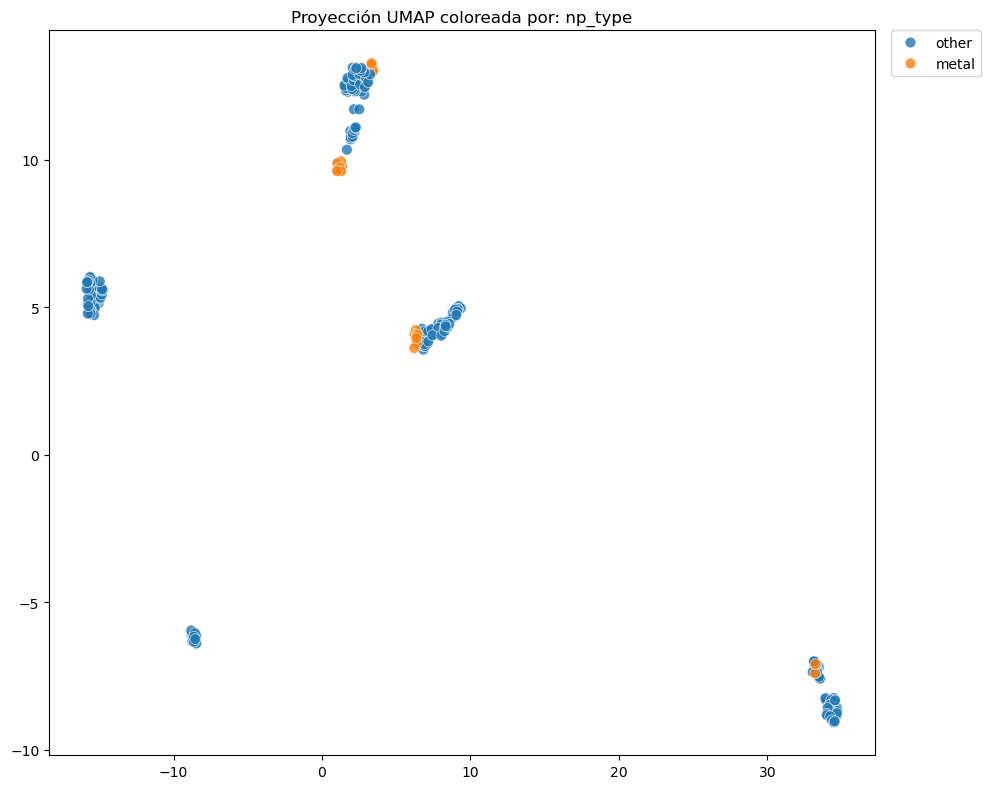

C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


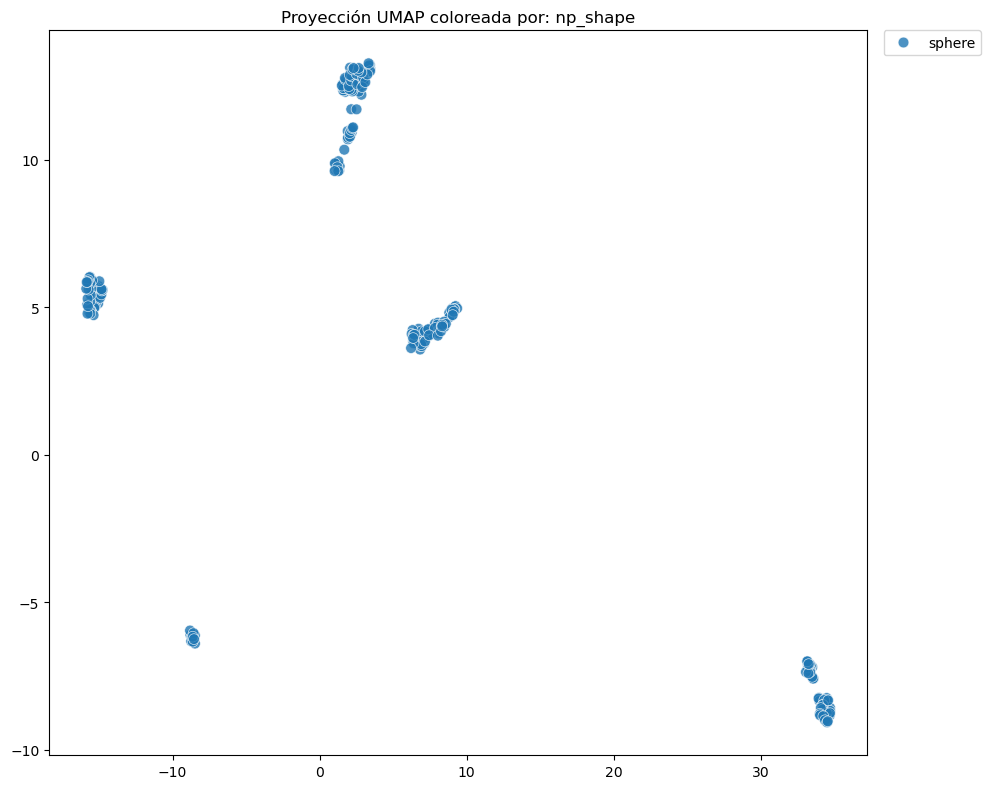

C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


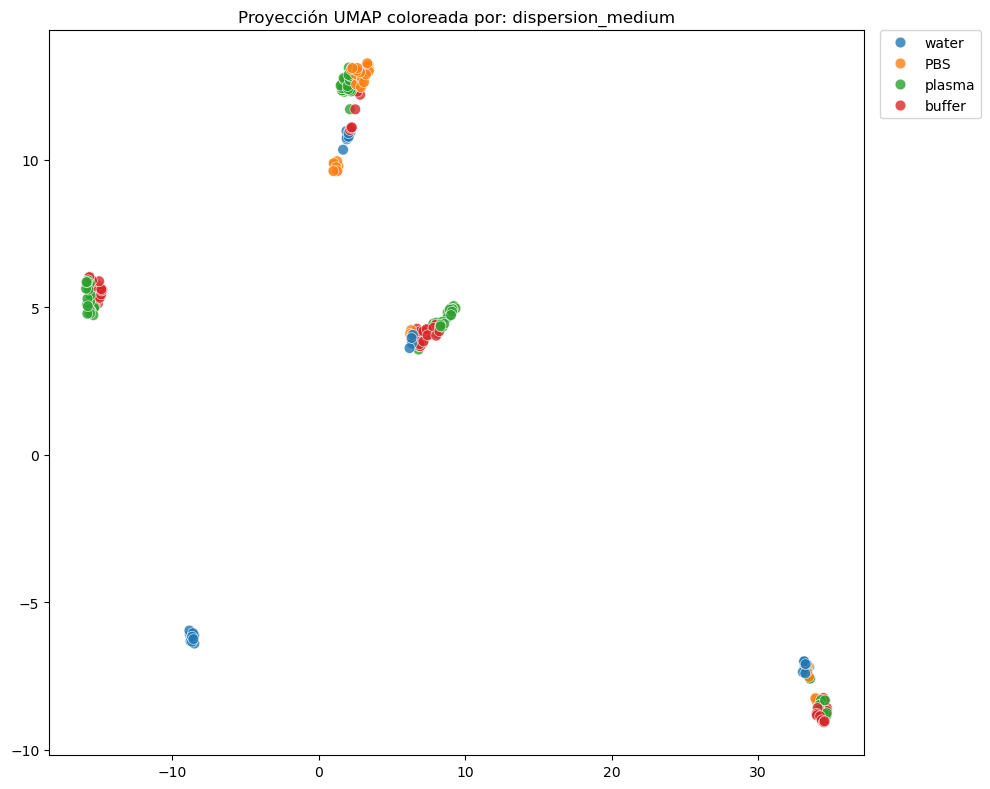

C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


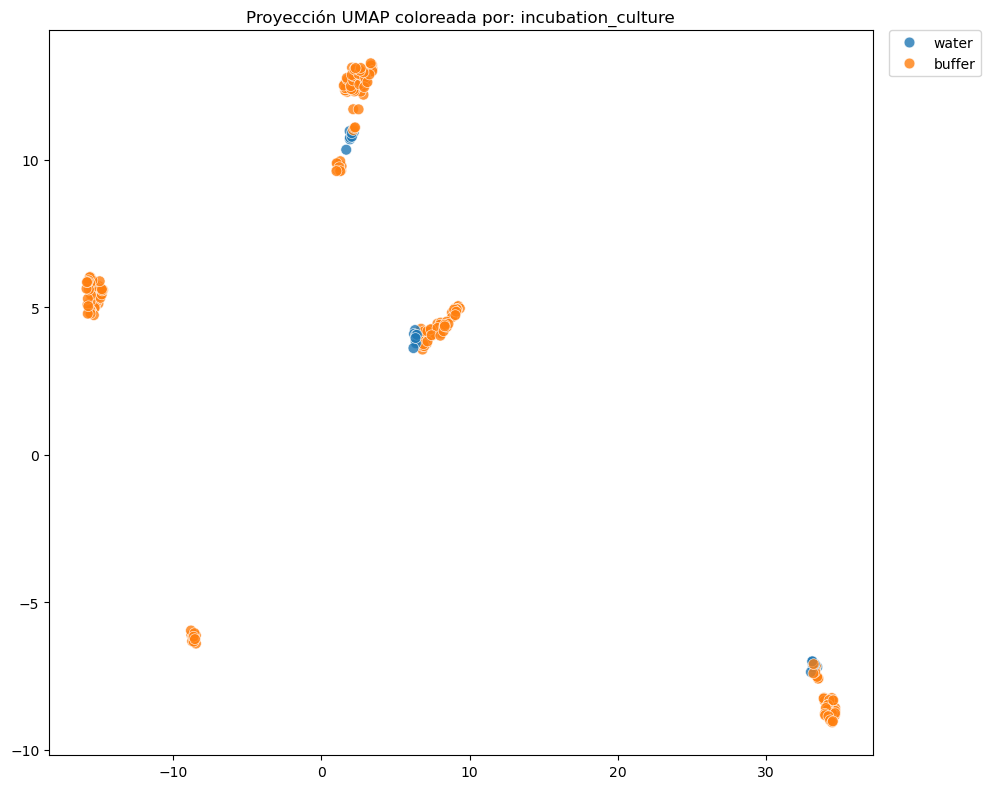

C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


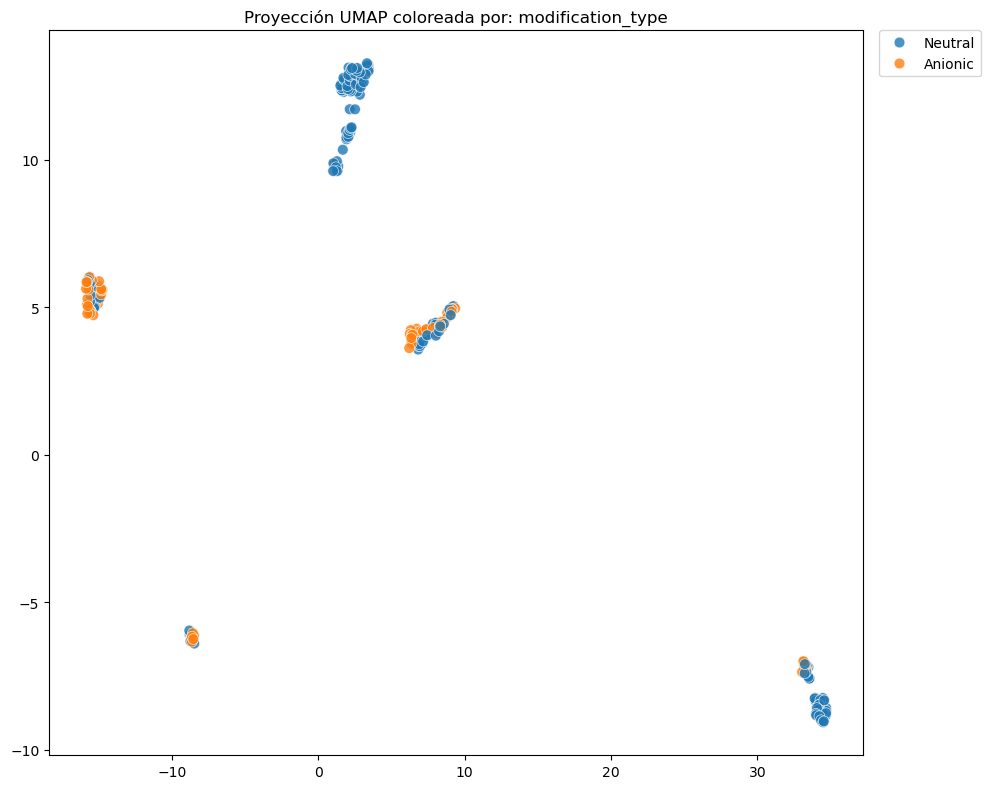

------------------------------------------------------------------------------
Proyección UMAP con la Metrica Jaccard


C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


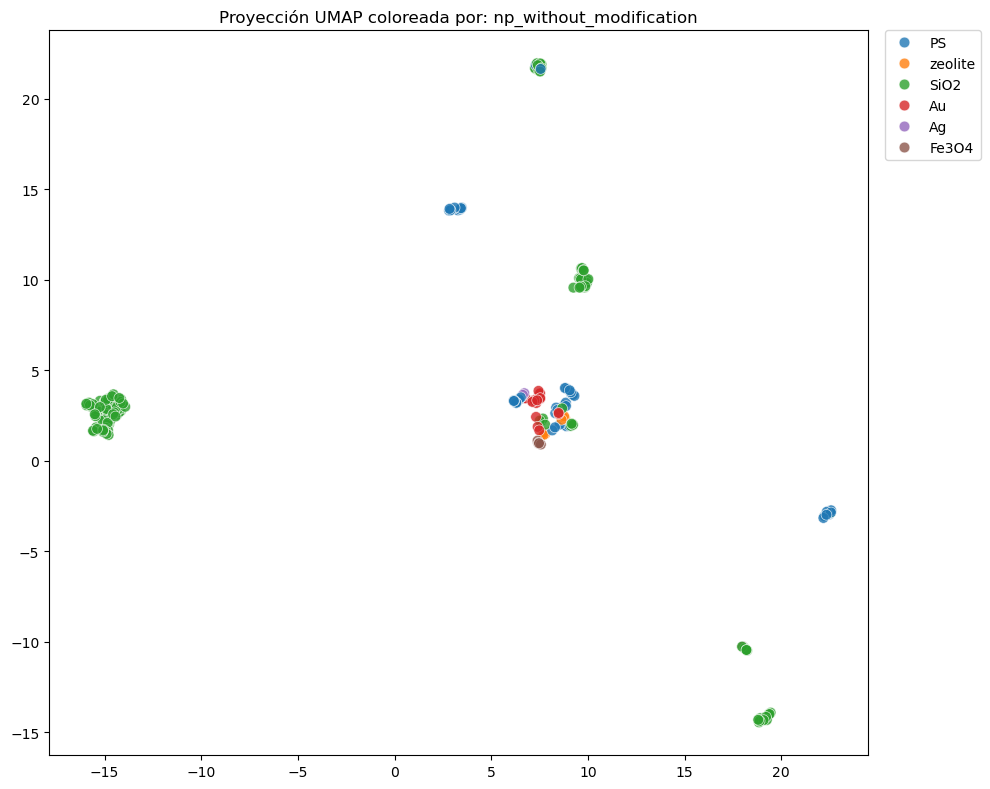

C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


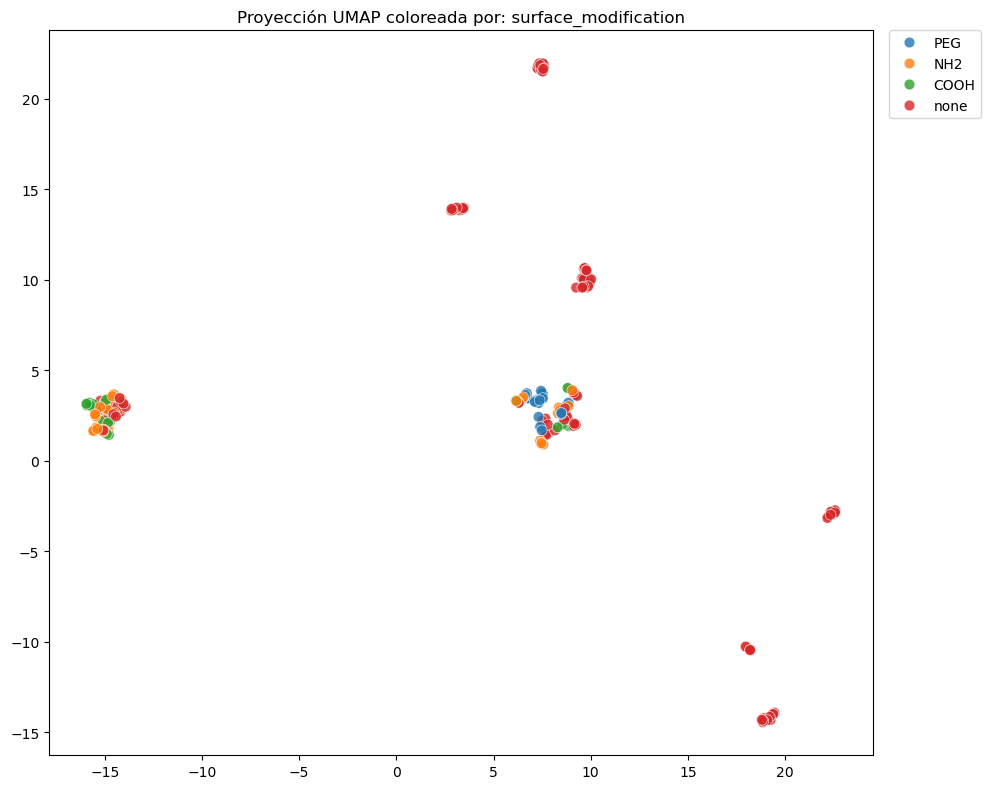

C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


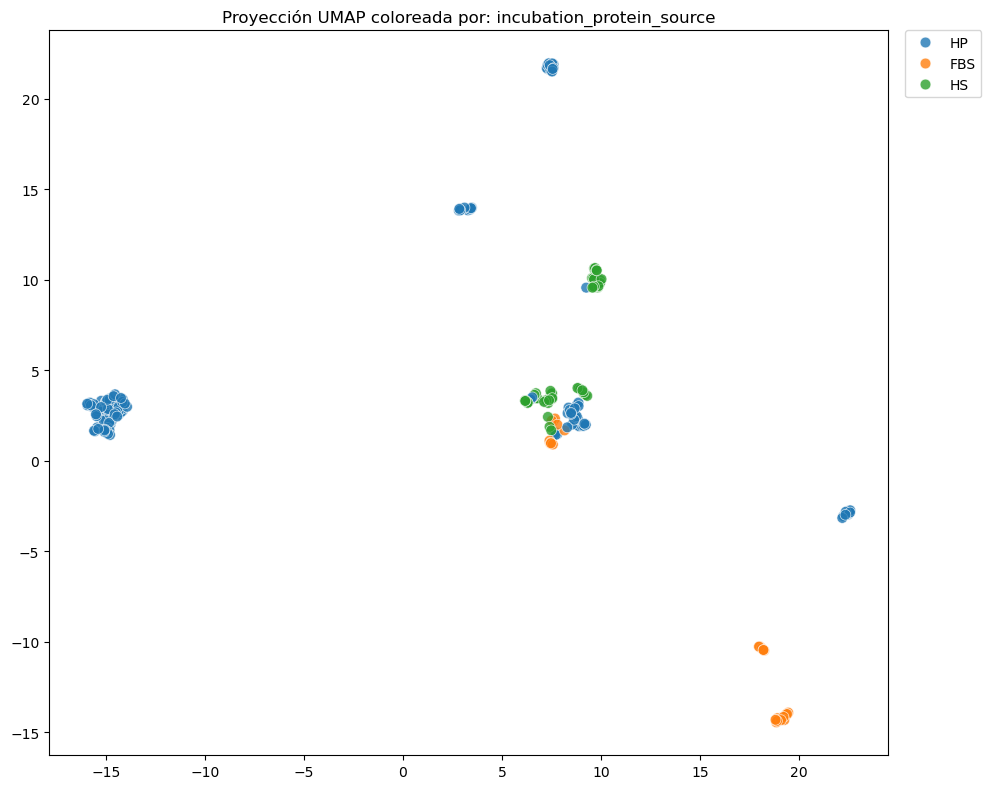

C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


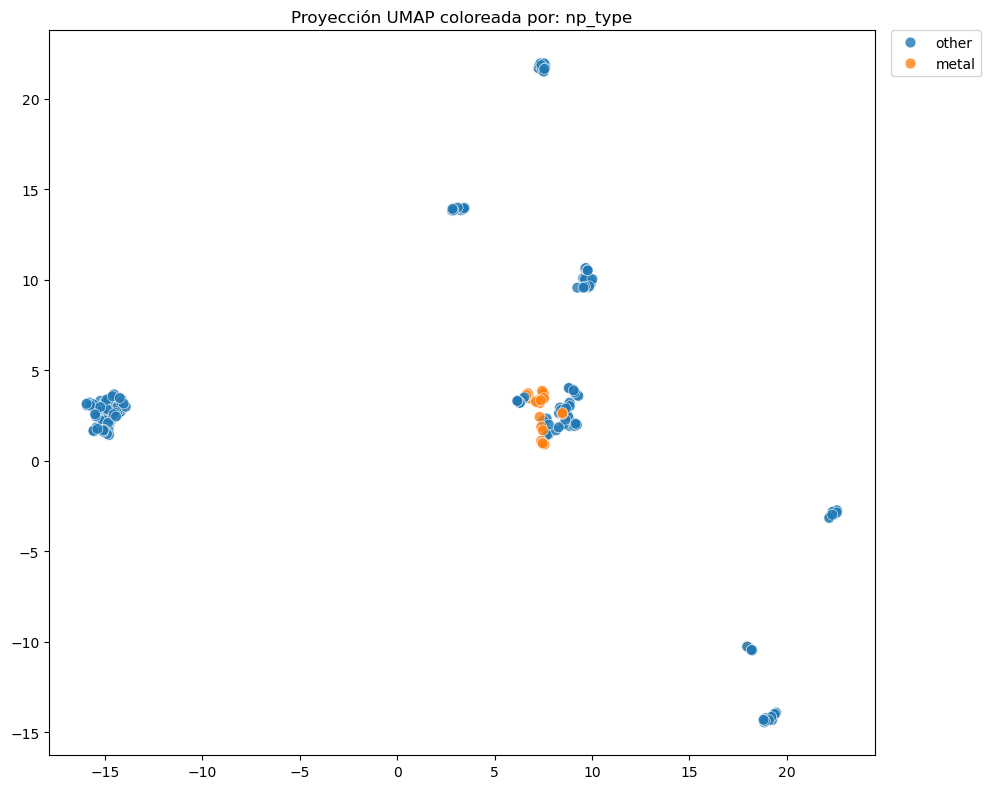

C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


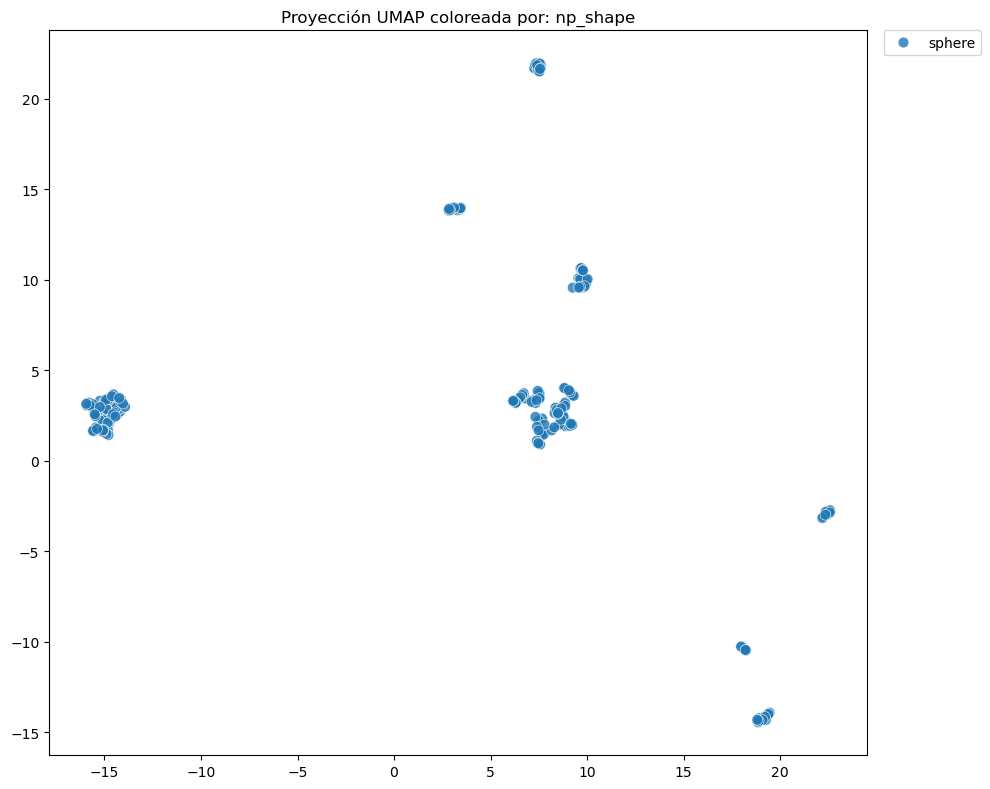

C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


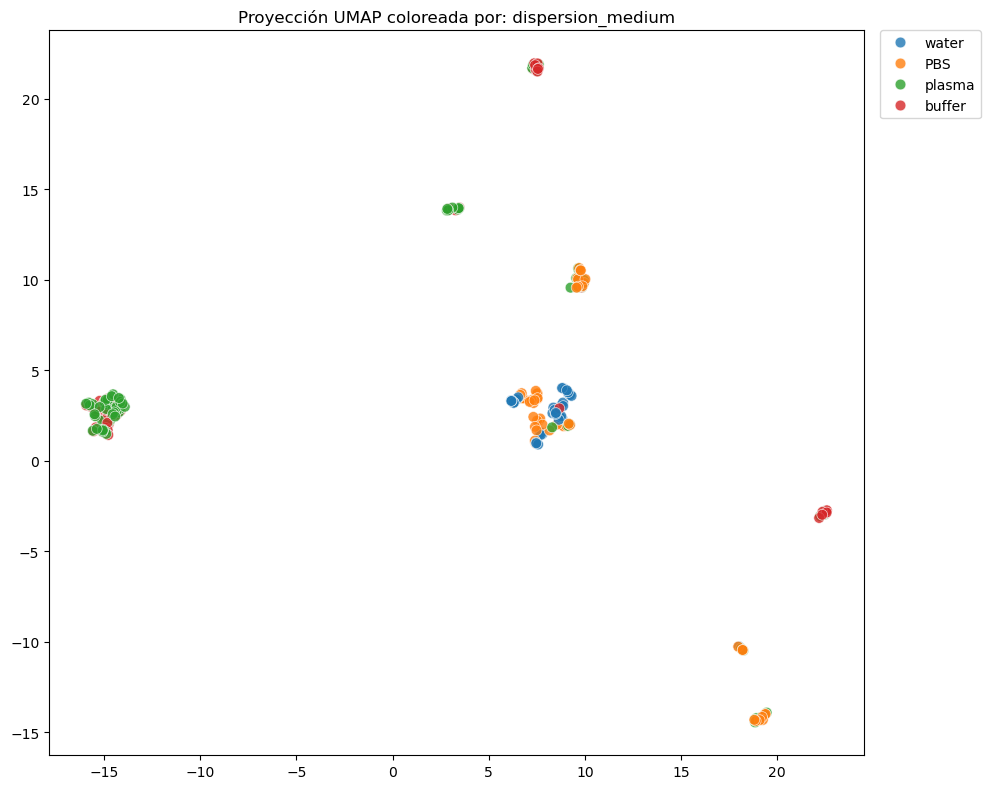

C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


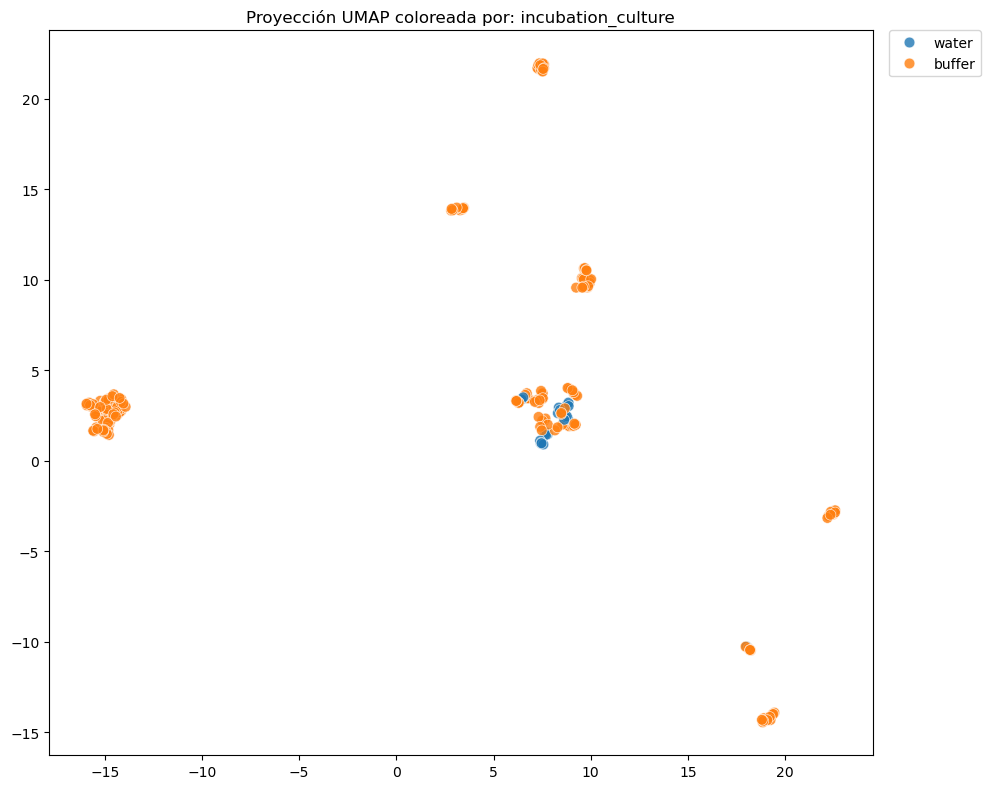

C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
C:\Users\emanu\miniconda3\envs\proteina-corona\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


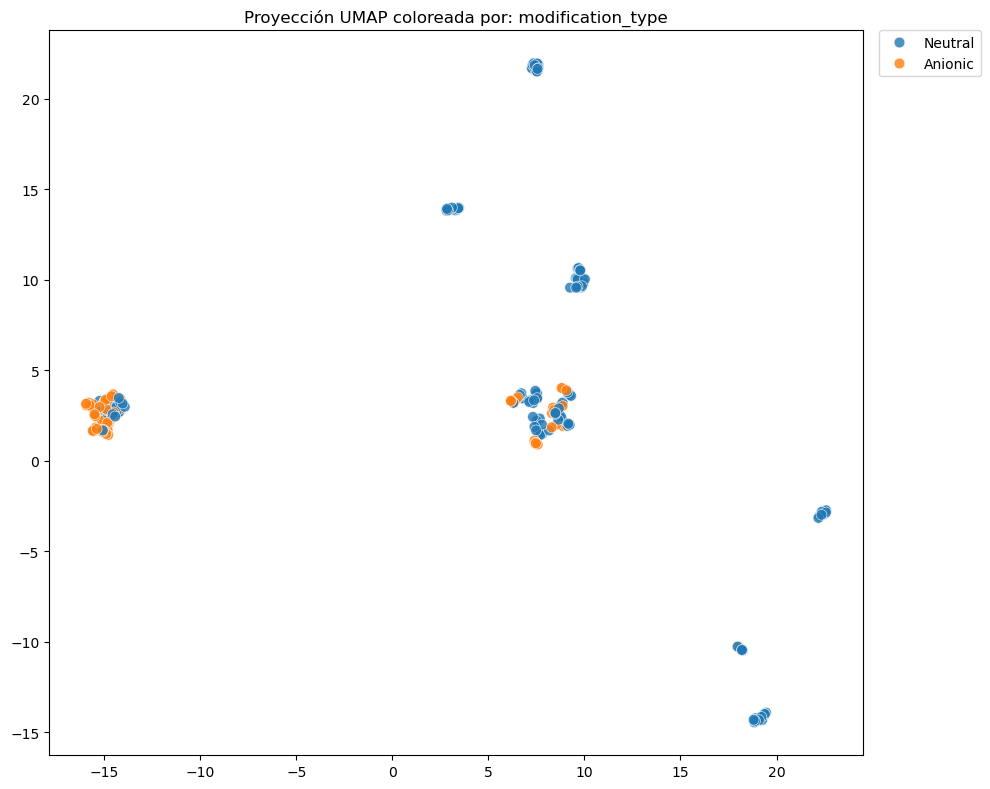

In [8]:
print("Proyección UMAP sin la Metrica Jaccard")
df = pd.read_csv('dataset_total_filtrado_frecuentes.csv')
umap_categorical_attributes(df, categorical_attributes=categorical_attributes)

print("------------------------------------------------------------------------------")
print("Proyección UMAP con la Metrica Jaccard")
df = pd.read_csv('dataset_total_filtrado_frecuentes_binary.csv')
umap_categorical_attributes(df, categorical_attributes=categorical_attributes, metric='jaccard')